# 04 — Prepare Raw Multimodal WESAD Windows for Deep Learning

This notebook constructs synchronized raw multimodal windows for subsequent deep-learning analyses. The file-discovery procedure accommodates alternative WESAD directory structures and compressed archives.

It is designed to be robust to common Google Drive path problems. It will:

1. Mount or remount Google Drive.
2. Search for raw WESAD `S*.pkl` files recursively.
3. Detect whether the dataset is uploaded as `.zip` but not extracted.
4. Load raw WESAD chest signals.
5. Downsample and window multimodal signals.
6. Save `X`, `y`, `subjects`, timestamps, and metadata for CNN/latent-state models.

Expected raw WESAD structure after extraction:

```text
Apple_Hidden_Wellness_AI/data/raw/WESAD/WESAD/S2/S2.pkl
Apple_Hidden_Wellness_AI/data/raw/WESAD/WESAD/S3/S3.pkl
...
```

or:

```text
Apple_Hidden_Wellness_AI/data/raw/WESAD/S2/S2.pkl
Apple_Hidden_Wellness_AI/data/raw/WESAD/S3/S3.pkl
...
```

In [ ]:
# ============================================================
# STEP 1. Imports and reproducibility
# ============================================================

import os
import glob
import json
import pickle
import random
import zipfile
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import resample_poly
from sklearn.preprocessing import StandardScaler

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

warnings.filterwarnings("ignore")

print("Imports complete.")

Imports complete.


In [ ]:
# ============================================================
# STEP 2. Mount Google Drive and define project paths
# ============================================================

# In Colab, this remounts Drive and refreshes recently uploaded/extracted files.
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
except Exception as e:
    print("Drive mount skipped or failed:", e)

PROJECT_ROOT = Path('/content/drive/MyDrive/Apple_Hidden_Wellness_AI')
DATA_DIR = PROJECT_ROOT / 'data'
RAW_DIR = DATA_DIR / 'raw'
PROCESSED_DIR = DATA_DIR / 'processed'
RESULTS_DIR = PROJECT_ROOT / 'results'
FIGURES_DIR = PROJECT_ROOT / 'figures'
RAW_WINDOW_DIR = PROCESSED_DIR / 'raw_multimodal_windows'

for d in [DATA_DIR, RAW_DIR, PROCESSED_DIR, RESULTS_DIR, FIGURES_DIR, RAW_WINDOW_DIR]:
    d.mkdir(parents=True, exist_ok=True)

RAW_WINDOW_NPZ = RAW_WINDOW_DIR / 'wesad_raw_multimodal_windows_32hz_60s_30s.npz'
METADATA_JSON = RAW_WINDOW_DIR / 'wesad_raw_multimodal_windows_metadata.json'
SUMMARY_CSV = RAW_WINDOW_DIR / 'wesad_raw_window_subject_summary.csv'

print('PROJECT_ROOT:', PROJECT_ROOT)
print('RAW_DIR     :', RAW_DIR)
print('OUTPUT NPZ  :', RAW_WINDOW_NPZ)

Mounted at /content/drive
PROJECT_ROOT: /content/drive/MyDrive/Apple_Hidden_Wellness_AI
RAW_DIR     : /content/drive/MyDrive/Apple_Hidden_Wellness_AI/data/raw
OUTPUT NPZ  : /content/drive/MyDrive/Apple_Hidden_Wellness_AI/data/processed/raw_multimodal_windows/wesad_raw_multimodal_windows_32hz_60s_30s.npz


In [ ]:
# ============================================================
# STEP 3. Robustly locate or extract raw WESAD dataset
# ============================================================

# This cell searches recursively because Google Drive sometimes has one extra WESAD/WESAD level.
# It also detects zip files if the raw dataset was uploaded but not extracted.

def print_tree_preview(base_dir, max_depth=5, max_items=12):
    base_dir = Path(base_dir)
    if not base_dir.exists():
        print(f"Directory does not exist: {base_dir}")
        return
    print(f"\nPreview of: {base_dir}")
    shown = 0
    for root, dirs, files in os.walk(base_dir):
        root_path = Path(root)
        depth = len(root_path.relative_to(base_dir).parts)
        if depth > max_depth:
            dirs[:] = []
            continue
        print('  ' * depth + f"{root_path.name}/")
        for f in files[:5]:
            print('  ' * (depth + 1) + f)
        shown += 1
        if shown >= max_items:
            print('  ... preview truncated ...')
            break

def find_subject_pkls(search_roots):
    found = []
    for search_root in search_roots:
        search_root = Path(search_root)
        if search_root.exists():
            # recursive search for S2.pkl, S3.pkl, etc.
            found.extend(search_root.rglob('S*.pkl'))
    # Keep files whose parent folder matches the file stem: S2/S2.pkl
    clean = []
    for p in found:
        if p.stem == p.parent.name and p.parent.name.startswith('S'):
            clean.append(p)
    return sorted(set(clean), key=lambda p: p.as_posix())

def infer_wesad_root_from_pkls(pkl_paths):
    # If files are .../WESAD/S2/S2.pkl, root is .../WESAD
    parent_roots = sorted(set([p.parent.parent for p in pkl_paths]))
    # Choose the root that contains the most subject pkl files
    counts = []
    for root in parent_roots:
        n = len([p for p in pkl_paths if p.parent.parent == root])
        counts.append((n, root))
    counts = sorted(counts, reverse=True, key=lambda x: x[0])
    return counts[0][1], counts

def find_zip_files(search_roots):
    zips = []
    for search_root in search_roots:
        search_root = Path(search_root)
        if search_root.exists():
            zips.extend(search_root.rglob('*.zip'))
    return sorted(set(zips), key=lambda p: p.as_posix())

search_roots = [
    RAW_DIR,
    PROJECT_ROOT,
    Path('/content/drive/MyDrive'),
]

print_tree_preview(RAW_DIR, max_depth=6, max_items=30)

subject_pkl_files = find_subject_pkls(search_roots)
print(f"\nFound subject .pkl files: {len(subject_pkl_files)}")
for p in subject_pkl_files[:10]:
    print(' ', p)

if len(subject_pkl_files) == 0:
    zip_files = find_zip_files(search_roots)
    print(f"\nFound zip files: {len(zip_files)}")
    for z in zip_files[:20]:
        print(' ', z)

    # Optional auto-extraction: if exactly one likely WESAD zip is found, extract it.
    likely_wesad_zips = [z for z in zip_files if 'wesad' in z.name.lower() or 'wesad' in str(z.parent).lower()]

    if len(likely_wesad_zips) >= 1:
        zip_path = likely_wesad_zips[0]
        extract_to = RAW_DIR / 'WESAD'
        extract_to.mkdir(parents=True, exist_ok=True)
        print(f"\nNo .pkl files found, but found a likely WESAD zip:")
        print(zip_path)
        print(f"Extracting to: {extract_to}")
        with zipfile.ZipFile(zip_path, 'r') as zf:
            zf.extractall(extract_to)
        print("Extraction complete. Searching again...")
        subject_pkl_files = find_subject_pkls(search_roots)
        print(f"Found subject .pkl files after extraction: {len(subject_pkl_files)}")
        for p in subject_pkl_files[:10]:
            print(' ', p)

if len(subject_pkl_files) == 0:
    raise FileNotFoundError(
        "Could not find WESAD S*.pkl files in Google Drive. "
        "Make sure the raw dataset is fully extracted, not only visible in the Drive web UI. "
        "Expected example: data/raw/WESAD/WESAD/S2/S2.pkl"
    )

WESAD_ROOT, root_counts = infer_wesad_root_from_pkls(subject_pkl_files)
subject_dirs = sorted(set([p.parent for p in subject_pkl_files]), key=lambda p: p.name)

print("\nSelected WESAD_ROOT:", WESAD_ROOT)
print("Number of subject folders:", len(subject_dirs))
print("Subject folders:", [p.name for p in subject_dirs])

# Save path info for later notebooks
path_info = {
    'project_root': str(PROJECT_ROOT),
    'wesad_root': str(WESAD_ROOT),
    'raw_window_npz': str(RAW_WINDOW_NPZ),
}
with open(RAW_WINDOW_DIR / 'path_info.json', 'w') as f:
    json.dump(path_info, f, indent=2)


Preview of: /content/drive/MyDrive/Apple_Hidden_Wellness_AI/data/raw
raw/
  WESAD/
    wesad-wearable-stress-affect-detection-dataset.zip
    WESAD/
      wesad_readme.pdf
      S10/
        S10.pkl
        S10_quest.csv
        S10_readme.txt
        S10_respiban.txt
        S10_E4_Data/
          ACC.csv
          BVP.csv
          EDA.csv
          HR.csv
          IBI.csv
      S11/
        S11.pkl
        S11_quest.csv
        S11_readme.txt
        S11_respiban.txt
        S11_E4_Data/
          ACC.csv
          BVP.csv
          EDA.csv
          HR.csv
          IBI.csv
      S13/
        S13.pkl
        S13_quest.csv
        S13_readme.txt
        S13_respiban.txt
        S13_E4_Data/
          ACC.csv
          BVP.csv
          EDA.csv
          HR.csv
          IBI.csv
      S14/
        S14.pkl
        S14_quest.csv
        S14_readme.txt
        S14_respiban.txt
        S14_E4_Data/
          ACC.csv
          BVP.csv
          EDA.csv
          HR.csv
          IBI.csv

In [ ]:
# ============================================================
# STEP 4. Raw-window configuration
# ============================================================

# WESAD chest signals and labels are sampled at 700 Hz.
ORIGINAL_FS = 700

# CNN-friendly target sampling rate. 32 Hz keeps the windows compact.
TARGET_FS = 32

# Window length and stride in seconds.
WINDOW_SEC = 60
STRIDE_SEC = 30

WINDOW_SAMPLES = WINDOW_SEC * TARGET_FS
STRIDE_SAMPLES = STRIDE_SEC * TARGET_FS

# Labels in WESAD:
# 1 = baseline, 2 = stress, 3 = amusement, 4 = meditation, others = transient/undefined.
# For binary stress classification, we keep only baseline and stress.
KEEP_ORIGINAL_LABELS = {1: 0, 2: 1}   # output: 0 baseline, 1 stress
LABEL_NAMES = {0: 'Baseline / Non-stress', 1: 'Stress'}
MIN_MAJORITY_FRAC = 0.80

# Chest modalities available in WESAD chest signal dictionary.
# ACC is 3-axis. Others are 1D.
CHANNELS = [
    'ACC_x', 'ACC_y', 'ACC_z',
    'ECG',
    'EDA',
    'EMG',
    'RESP',
    'TEMP'
]

print('Target sampling rate:', TARGET_FS, 'Hz')
print('Window samples:', WINDOW_SAMPLES)
print('Stride samples:', STRIDE_SAMPLES)
print('Channels:', CHANNELS)

Target sampling rate: 32 Hz
Window samples: 1920
Stride samples: 960
Channels: ['ACC_x', 'ACC_y', 'ACC_z', 'ECG', 'EDA', 'EMG', 'RESP', 'TEMP']


In [ ]:
# ============================================================
# STEP 5. Helper functions for loading, resampling, and windowing
# ============================================================

# WESAD chest-signal keys are handled case-insensitively to accommodate
# variations such as "Temp"/"TEMP" and "Resp"/"RESP".

def load_subject_pickle_from_file(pkl_path):
    pkl_path = Path(pkl_path)
    subject_id = pkl_path.stem
    with open(pkl_path, 'rb') as f:
        data = pickle.load(f, encoding='latin1')
    return subject_id, data


def _get_chest_key(chest, possible_keys):
    """Return chest[possible_key] using a case-flexible lookup."""
    for key in possible_keys:
        if key in chest:
            return chest[key]
    available = list(chest.keys())
    raise KeyError(f"Could not find any of {possible_keys}. Available chest keys: {available}")


def get_chest_signals(data, verbose=False):
    """
    Return synchronized WESAD chest signal matrix with channels in CHANNELS order.

    Output channel order:
        ACC_x, ACC_y, ACC_z, ECG, EDA, EMG, RESP, TEMP
    """
    chest = data['signal']['chest']

    if verbose:
        print('Available chest keys:', list(chest.keys()))

    acc = np.asarray(_get_chest_key(chest, ['ACC']), dtype=np.float32)
    if acc.ndim != 2 or acc.shape[1] != 3:
        raise ValueError(f"Unexpected ACC shape: {acc.shape}")

    ecg  = np.asarray(_get_chest_key(chest, ['ECG', 'ecg'])).reshape(-1).astype(np.float32)
    eda  = np.asarray(_get_chest_key(chest, ['EDA', 'eda'])).reshape(-1).astype(np.float32)
    emg  = np.asarray(_get_chest_key(chest, ['EMG', 'emg'])).reshape(-1).astype(np.float32)
    resp = np.asarray(_get_chest_key(chest, ['Resp', 'RESP', 'resp'])).reshape(-1).astype(np.float32)
    temp = np.asarray(_get_chest_key(chest, ['Temp', 'TEMP', 'temp'])).reshape(-1).astype(np.float32)

    arrays = [
        acc[:, 0],
        acc[:, 1],
        acc[:, 2],
        ecg,
        eda,
        emg,
        resp,
        temp,
    ]

    min_len = min(len(a) for a in arrays)
    X = np.stack([a[:min_len] for a in arrays], axis=1).astype(np.float32)
    return X


def get_labels(data, length):
    labels = np.asarray(data['label']).reshape(-1).astype(int)
    return labels[:length]


def downsample_signals_and_labels(X_raw, y_raw, original_fs=700, target_fs=32):
    """Downsample signals using polyphase filtering and labels using nearest indexing."""
    # 700 -> 32, use rational ratio 32/700.
    up = target_fs
    down = original_fs
    X_ds = resample_poly(X_raw, up=up, down=down, axis=0).astype(np.float32)

    # Assign label for each downsampled timepoint by nearest original sample index.
    n_ds = X_ds.shape[0]
    t_ds = np.arange(n_ds) / target_fs
    orig_idx = np.minimum((t_ds * original_fs).astype(int), len(y_raw) - 1)
    y_ds = y_raw[orig_idx].astype(int)
    return X_ds, y_ds


def window_subject(X_ds, y_ds, subject_id):
    """Create fixed-length overlapping windows for one subject."""
    X_windows = []
    y_windows = []
    start_seconds = []
    majority_fracs = []
    original_majority_labels = []

    n = min(len(X_ds), len(y_ds))
    X_ds = X_ds[:n]
    y_ds = y_ds[:n]

    for start in range(0, n - WINDOW_SAMPLES + 1, STRIDE_SAMPLES):
        end = start + WINDOW_SAMPLES
        y_win_raw = y_ds[start:end]

        # Keep only windows dominated by baseline or stress.
        mask = np.isin(y_win_raw, list(KEEP_ORIGINAL_LABELS.keys()))
        if mask.mean() < MIN_MAJORITY_FRAC:
            continue

        valid_labels = y_win_raw[mask]
        unique, counts = np.unique(valid_labels, return_counts=True)
        maj_original = int(unique[np.argmax(counts)])
        maj_frac = float(np.max(counts) / len(y_win_raw))

        if maj_original not in KEEP_ORIGINAL_LABELS:
            continue

        X_windows.append(X_ds[start:end].astype(np.float32))
        y_windows.append(KEEP_ORIGINAL_LABELS[maj_original])
        start_seconds.append(start / TARGET_FS)
        majority_fracs.append(maj_frac)
        original_majority_labels.append(maj_original)

    if len(X_windows) == 0:
        return (
            np.empty((0, WINDOW_SAMPLES, len(CHANNELS)), dtype=np.float32),
            np.array([], dtype=np.int64),
            np.array([], dtype=np.float32),
            np.array([], dtype=np.float32),
            np.array([], dtype=np.int64),
        )

    return (
        np.stack(X_windows).astype(np.float32),
        np.asarray(y_windows, dtype=np.int64),
        np.asarray(start_seconds, dtype=np.float32),
        np.asarray(majority_fracs, dtype=np.float32),
        np.asarray(original_majority_labels, dtype=np.int64),
    )


def subject_normalize_windows(X_win):
    """Within-subject channel-wise z-score normalization."""
    mean = X_win.reshape(-1, X_win.shape[-1]).mean(axis=0)
    std = X_win.reshape(-1, X_win.shape[-1]).std(axis=0)
    std = np.where(std < 1e-8, 1.0, std)
    X_norm = (X_win - mean) / std
    return X_norm.astype(np.float32), mean.astype(np.float32), std.astype(np.float32)

print('Step 5 functions loaded successfully.')
print('Expected channel order:', CHANNELS)



Step 5 functions loaded successfully.
Expected channel order: ['ACC_x', 'ACC_y', 'ACC_z', 'ECG', 'EDA', 'EMG', 'RESP', 'TEMP']


In [ ]:
# ============================================================
# STEP 6. Build raw multimodal windows
# ============================================================

all_X = []
all_y = []
all_subjects = []
all_start_sec = []
all_majority_frac = []
all_original_label = []
summary_rows = []
normalization_stats = {}
failed_subjects = []

print('Number of subject PKL files discovered:', len(subject_pkl_files))
print('Subject files:')
for p in subject_pkl_files:
    print(' ', p)

for idx, pkl_path in enumerate(subject_pkl_files):
    subject_id, data = load_subject_pickle_from_file(pkl_path)
    print(f"\nProcessing {subject_id}: {pkl_path}")

    try:
        X_raw = get_chest_signals(data, verbose=(idx == 0))
        y_raw = get_labels(data, len(X_raw))

        print('  raw signal shape:', X_raw.shape, 'raw label shape:', y_raw.shape)

        X_ds, y_ds = downsample_signals_and_labels(X_raw, y_raw, ORIGINAL_FS, TARGET_FS)
        print('  downsampled shape:', X_ds.shape)

        X_win, y_win, start_sec_sub, maj_frac_sub, orig_lab_sub = window_subject(X_ds, y_ds, subject_id)
        print('  accepted windows:', len(y_win), '| baseline:', int(np.sum(y_win == 0)), '| stress:', int(np.sum(y_win == 1)))

        summary_rows.append({
            'subject': subject_id,
            'pkl_path': str(pkl_path),
            'status': 'processed',
            'n_windows': int(len(y_win)),
            'baseline_windows': int(np.sum(y_win == 0)),
            'stress_windows': int(np.sum(y_win == 1)),
            'duration_min_downsampled': float(len(y_ds) / TARGET_FS / 60),
            'raw_samples': int(len(X_raw)),
            'downsampled_samples': int(len(X_ds)),
        })

        if len(y_win) == 0:
            continue

        X_win_norm, ch_mean, ch_std = subject_normalize_windows(X_win)
        normalization_stats[subject_id] = {
            'mean': ch_mean.tolist(),
            'std': ch_std.tolist(),
        }

        all_X.append(X_win_norm)
        all_y.append(y_win)
        all_subjects.extend([subject_id] * len(y_win))
        all_start_sec.extend(start_sec_sub.tolist())
        all_majority_frac.extend(maj_frac_sub.tolist())
        all_original_label.extend(orig_lab_sub.tolist())

    except Exception as e:
        print(f'  ERROR processing {subject_id}: {repr(e)}')
        failed_subjects.append({'subject': subject_id, 'pkl_path': str(pkl_path), 'error': repr(e)})
        summary_rows.append({
            'subject': subject_id,
            'pkl_path': str(pkl_path),
            'status': 'failed',
            'error': repr(e),
            'n_windows': 0,
            'baseline_windows': 0,
            'stress_windows': 0,
            'duration_min_downsampled': np.nan,
            'raw_samples': np.nan,
            'downsampled_samples': np.nan,
        })

if len(all_X) == 0:
    raise RuntimeError(
        'No valid windows were generated. Check WESAD_ROOT, label filtering, and window settings.'
    )

X = np.concatenate(all_X, axis=0).astype(np.float32)
y = np.concatenate(all_y, axis=0).astype(np.int64)
subjects = np.asarray(all_subjects)
start_sec = np.asarray(all_start_sec, dtype=np.float32)
majority_frac = np.asarray(all_majority_frac, dtype=np.float32)
original_label = np.asarray(all_original_label, dtype=np.int64)

summary_df = pd.DataFrame(summary_rows)

print('\nFinal raw-window dataset:')
print('X:', X.shape)
print('y:', y.shape)
print('subjects:', subjects.shape)
print('Unique subjects:', np.unique(subjects))
print('Class counts:', dict(zip(*np.unique(y, return_counts=True))))

if failed_subjects:
    print('\nFailed subjects:')
    for row in failed_subjects:
        print(row)

summary_df



Number of subject PKL files discovered: 15
Subject files:
  /content/drive/MyDrive/Apple_Hidden_Wellness_AI/data/raw/WESAD/WESAD/S10/S10.pkl
  /content/drive/MyDrive/Apple_Hidden_Wellness_AI/data/raw/WESAD/WESAD/S11/S11.pkl
  /content/drive/MyDrive/Apple_Hidden_Wellness_AI/data/raw/WESAD/WESAD/S13/S13.pkl
  /content/drive/MyDrive/Apple_Hidden_Wellness_AI/data/raw/WESAD/WESAD/S14/S14.pkl
  /content/drive/MyDrive/Apple_Hidden_Wellness_AI/data/raw/WESAD/WESAD/S15/S15.pkl
  /content/drive/MyDrive/Apple_Hidden_Wellness_AI/data/raw/WESAD/WESAD/S16/S16.pkl
  /content/drive/MyDrive/Apple_Hidden_Wellness_AI/data/raw/WESAD/WESAD/S17/S17.pkl
  /content/drive/MyDrive/Apple_Hidden_Wellness_AI/data/raw/WESAD/WESAD/S2/S2.pkl
  /content/drive/MyDrive/Apple_Hidden_Wellness_AI/data/raw/WESAD/WESAD/S3/S3.pkl
  /content/drive/MyDrive/Apple_Hidden_Wellness_AI/data/raw/WESAD/WESAD/S4/S4.pkl
  /content/drive/MyDrive/Apple_Hidden_Wellness_AI/data/raw/WESAD/WESAD/S5/S5.pkl
  /content/drive/MyDrive/Apple_Hidden

,subject,pkl_path,status,n_windows,baseline_windows,stress_windows,duration_min_downsampled,raw_samples,downsampled_samples
0,S10,/content/drive/MyDrive/Apple_Hidden_Wellness_A...,processed,60,38,22,91.600000,3847200,175872
1,S11,/content/drive/MyDrive/Apple_Hidden_Wellness_A...,processed,59,38,21,87.216667,3663100,167456
2,S13,/content/drive/MyDrive/Apple_Hidden_Wellness_A...,processed,59,38,21,92.283333,3875900,177184
3,S14,/content/drive/MyDrive/Apple_Hidden_Wellness_A...,processed,59,38,21,92.466667,3883600,177536
4,S15,/content/drive/MyDrive/Apple_Hidden_Wellness_A...,processed,60,38,22,87.533333,3676400,168064
5,S16,/content/drive/MyDrive/Apple_Hidden_Wellness_A...,processed,61,39,22,93.850000,3941700,180192
6,S17,/content/drive/MyDrive/Apple_Hidden_Wellness_A...,processed,61,38,23,98.666667,4144000,189440
7,S2,/content/drive/MyDrive/Apple_Hidden_Wellness_A...,processed,56,37,19,101.316667,4255300,194528
8,S3,/content/drive/MyDrive/Apple_Hidden_Wellness_A...,processed,57,37,20,108.216667,4545100,207776
9,S4,/content/drive/MyDrive/Apple_Hidden_Wellness_A...,processed,57,37,20,107.050000,4496100,205536


In [ ]:
# ============================================================
# STEP 7. Save dataset, metadata, and summary files
# ============================================================

np.savez_compressed(
    RAW_WINDOW_NPZ,
    X=X,
    y=y,
    subjects=subjects,
    start_sec=start_sec,
    majority_frac=majority_frac,
    original_label=original_label,
    channels=np.asarray(CHANNELS),
)

summary_df.to_csv(SUMMARY_CSV, index=False)

metadata = {
    'project_root': str(PROJECT_ROOT),
    'wesad_root': str(WESAD_ROOT),
    'raw_window_npz': str(RAW_WINDOW_NPZ),
    'summary_csv': str(SUMMARY_CSV),
    'original_fs': ORIGINAL_FS,
    'target_fs': TARGET_FS,
    'window_sec': WINDOW_SEC,
    'stride_sec': STRIDE_SEC,
    'window_samples': WINDOW_SAMPLES,
    'stride_samples': STRIDE_SAMPLES,
    'channels': CHANNELS,
    'label_names': LABEL_NAMES,
    'keep_original_labels': KEEP_ORIGINAL_LABELS,
    'min_majority_frac': MIN_MAJORITY_FRAC,
    'n_windows': int(X.shape[0]),
    'n_subjects': int(len(np.unique(subjects))),
    'class_counts': {str(k): int(v) for k, v in zip(*np.unique(y, return_counts=True))},
    'normalization': 'within-subject channel-wise z-score before concatenation',
    'normalization_stats': normalization_stats,
}

with open(METADATA_JSON, 'w') as f:
    json.dump(metadata, f, indent=2)

print('Saved raw window dataset to:')
print(RAW_WINDOW_NPZ)
print('Saved metadata to:')
print(METADATA_JSON)
print('Saved subject summary to:')
print(SUMMARY_CSV)

Saved raw window dataset to:
/content/drive/MyDrive/Apple_Hidden_Wellness_AI/data/processed/raw_multimodal_windows/wesad_raw_multimodal_windows_32hz_60s_30s.npz
Saved metadata to:
/content/drive/MyDrive/Apple_Hidden_Wellness_AI/data/processed/raw_multimodal_windows/wesad_raw_multimodal_windows_metadata.json
Saved subject summary to:
/content/drive/MyDrive/Apple_Hidden_Wellness_AI/data/processed/raw_multimodal_windows/wesad_raw_window_subject_summary.csv


In [ ]:
# ============================================================
# STEP 8. Quick quality checks
# ============================================================

print('Any NaN in X?', np.isnan(X).any())
print('Any Inf in X?', np.isinf(X).any())
print('X dtype:', X.dtype)
print('y dtype:', y.dtype)

print('\nWindow counts by subject and class:')
display(pd.crosstab(pd.Series(subjects, name='subject'), pd.Series(y, name='label')))

print('\nSummary:')
display(summary_df)

Any NaN in X? False
Any Inf in X? False
X dtype: float32
y dtype: int64

Window counts by subject and class:


label,0,1
subject,,
S10,38,22
S11,38,21
S13,38,21
S14,38,21
S15,38,22
S16,39,22
S17,38,23
S2,37,19
S3,37,20



Summary:


,subject,pkl_path,status,n_windows,baseline_windows,stress_windows,duration_min_downsampled,raw_samples,downsampled_samples
0,S10,/content/drive/MyDrive/Apple_Hidden_Wellness_A...,processed,60,38,22,91.600000,3847200,175872
1,S11,/content/drive/MyDrive/Apple_Hidden_Wellness_A...,processed,59,38,21,87.216667,3663100,167456
2,S13,/content/drive/MyDrive/Apple_Hidden_Wellness_A...,processed,59,38,21,92.283333,3875900,177184
3,S14,/content/drive/MyDrive/Apple_Hidden_Wellness_A...,processed,59,38,21,92.466667,3883600,177536
4,S15,/content/drive/MyDrive/Apple_Hidden_Wellness_A...,processed,60,38,22,87.533333,3676400,168064
5,S16,/content/drive/MyDrive/Apple_Hidden_Wellness_A...,processed,61,39,22,93.850000,3941700,180192
6,S17,/content/drive/MyDrive/Apple_Hidden_Wellness_A...,processed,61,38,23,98.666667,4144000,189440
7,S2,/content/drive/MyDrive/Apple_Hidden_Wellness_A...,processed,56,37,19,101.316667,4255300,194528
8,S3,/content/drive/MyDrive/Apple_Hidden_Wellness_A...,processed,57,37,20,108.216667,4545100,207776
9,S4,/content/drive/MyDrive/Apple_Hidden_Wellness_A...,processed,57,37,20,107.050000,4496100,205536


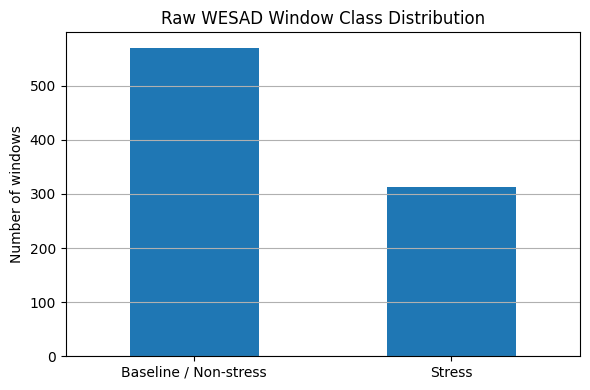

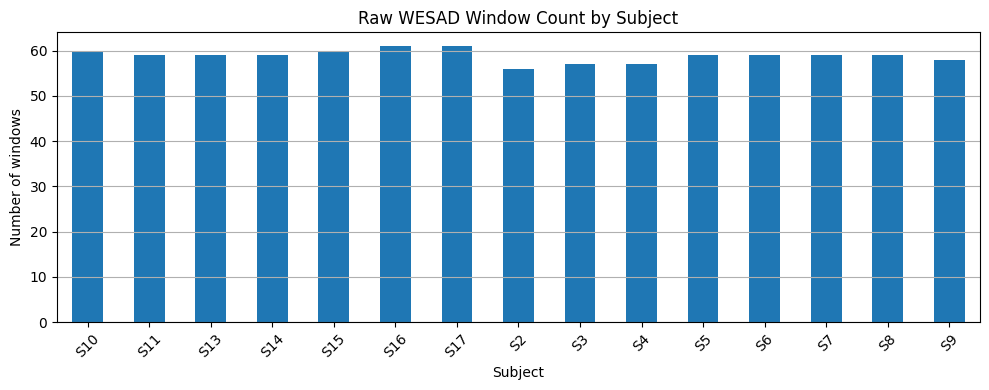

In [ ]:
# ============================================================
# STEP 9. Visualize class and subject distribution
# ============================================================

class_counts = pd.Series(y).map(LABEL_NAMES).value_counts().reindex([LABEL_NAMES[0], LABEL_NAMES[1]])

plt.figure(figsize=(6, 4))
class_counts.plot(kind='bar')
plt.title('Raw WESAD Window Class Distribution')
plt.ylabel('Number of windows')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'raw_window_class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

subject_counts = pd.Series(subjects).value_counts().sort_index()
plt.figure(figsize=(10, 4))
subject_counts.plot(kind='bar')
plt.title('Raw WESAD Window Count by Subject')
plt.ylabel('Number of windows')
plt.xlabel('Subject')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'raw_window_count_by_subject.png', dpi=300, bbox_inches='tight')
plt.show()

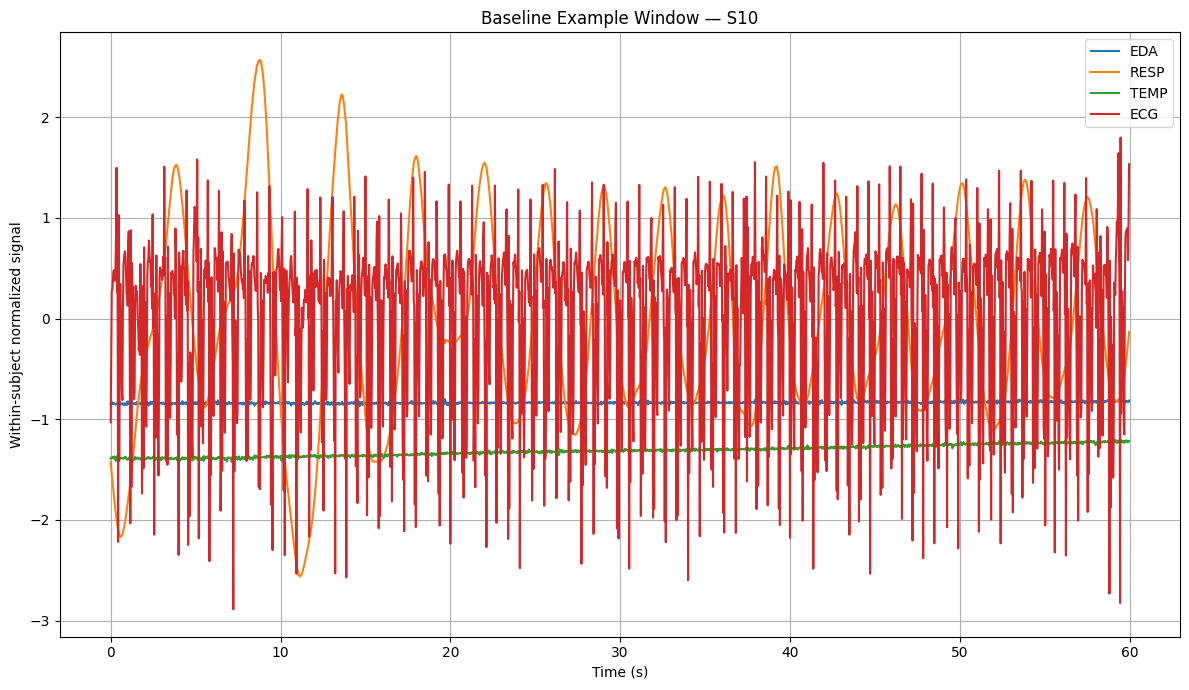

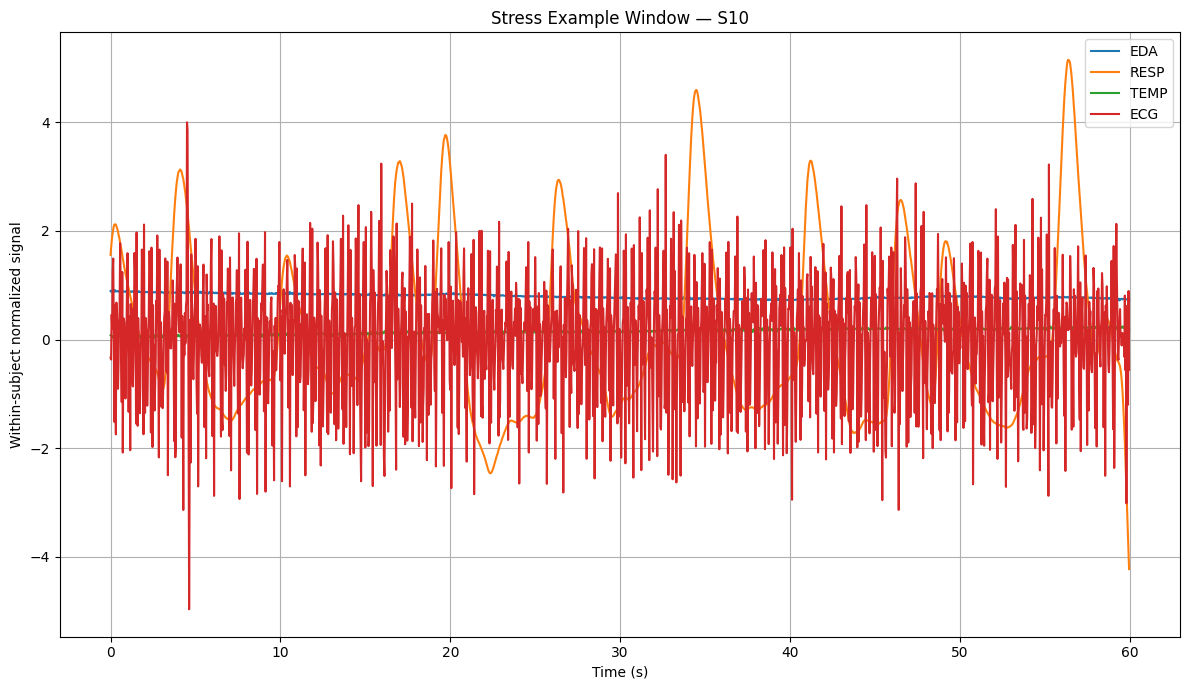

In [ ]:
# ============================================================
# STEP 10. Plot example raw normalized windows
# ============================================================

# Pick one baseline and one stress window.
time_axis = np.arange(WINDOW_SAMPLES) / TARGET_FS

def plot_example_window(class_value, title):
    idxs = np.where(y == class_value)[0]
    if len(idxs) == 0:
        print('No windows for class', class_value)
        return
    idx = idxs[0]
    xw = X[idx]
    subject_id = subjects[idx]

    selected_channels = ['EDA', 'RESP', 'TEMP', 'ECG']
    plt.figure(figsize=(12, 7))
    for ch in selected_channels:
        ch_idx = CHANNELS.index(ch)
        plt.plot(time_axis, xw[:, ch_idx], label=ch)
    plt.title(f'{title} Example Window — {subject_id}')
    plt.xlabel('Time (s)')
    plt.ylabel('Within-subject normalized signal')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    fname = title.lower().replace(' ', '_').replace('/', '_') + '_example_raw_window.png'
    plt.savefig(FIGURES_DIR / fname, dpi=300, bbox_inches='tight')
    plt.show()

plot_example_window(0, 'Baseline')
plot_example_window(1, 'Stress')

In [ ]:
# ============================================================
# STEP 11. Reload test for next notebooks
# ============================================================

loaded = np.load(RAW_WINDOW_NPZ, allow_pickle=True)
X_test = loaded['X']
y_test = loaded['y']
subjects_test = loaded['subjects']
channels_test = loaded['channels']

print('Reload successful.')
print('X_test:', X_test.shape)
print('y_test:', y_test.shape)
print('subjects_test:', subjects_test.shape)
print('channels_test:', channels_test.tolist())

assert X_test.shape == X.shape
assert y_test.shape == y.shape
assert subjects_test.shape == subjects.shape
print('All checks passed.')

Reload successful.
X_test: (883, 1920, 8)
y_test: (883,)
subjects_test: (883,)
channels_test: ['ACC_x', 'ACC_y', 'ACC_z', 'ECG', 'EDA', 'EMG', 'RESP', 'TEMP']
All checks passed.


In [ ]:
# ============================================================
# STEP 11. Diagnostic check: subject completeness
# ============================================================

expected_subjects = ['S2','S3','S4','S5','S6','S7','S8','S9','S10','S11','S13','S14','S15','S16','S17']
found_subjects = sorted([Path(p).stem for p in subject_pkl_files])
processed_subjects = sorted(np.unique(subjects).tolist()) if 'subjects' in globals() else []

completeness_rows = []
for sid in expected_subjects:
    pkl_matches = [str(p) for p in subject_pkl_files if Path(p).stem == sid]
    n_windows = int(np.sum(subjects == sid)) if 'subjects' in globals() else 0
    completeness_rows.append({
        'subject': sid,
        'pkl_found': len(pkl_matches) > 0,
        'pkl_path': pkl_matches[0] if pkl_matches else '',
        'processed_windows': n_windows,
        'included_in_final_dataset': n_windows > 0,
    })

completeness_df = pd.DataFrame(completeness_rows)
print('Expected subjects:', len(expected_subjects))
print('PKL files found:', len(found_subjects), found_subjects)
print('Subjects included in final dataset:', len(processed_subjects), processed_subjects)

missing_pkl = completeness_df.loc[~completeness_df['pkl_found'], 'subject'].tolist()
missing_windows = completeness_df.loc[completeness_df['pkl_found'] & ~completeness_df['included_in_final_dataset'], 'subject'].tolist()

print('Missing PKL files:', missing_pkl)
print('PKL found but no accepted windows:', missing_windows)

# Save diagnostic table if output directory is available.
if 'OUTPUT_DIR' in globals():
    diagnostic_path = OUTPUT_DIR / 'raw_window_subject_completeness_diagnostic.csv'
    completeness_df.to_csv(diagnostic_path, index=False)
    print('Saved diagnostic table to:', diagnostic_path)

completeness_df



Expected subjects: 15
PKL files found: 15 ['S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9']
Subjects included in final dataset: 15 ['S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9']
Missing PKL files: []
PKL found but no accepted windows: []


,subject,pkl_found,pkl_path,processed_windows,included_in_final_dataset
0,S2,True,/content/drive/MyDrive/Apple_Hidden_Wellness_A...,56,True
1,S3,True,/content/drive/MyDrive/Apple_Hidden_Wellness_A...,57,True
2,S4,True,/content/drive/MyDrive/Apple_Hidden_Wellness_A...,57,True
3,S5,True,/content/drive/MyDrive/Apple_Hidden_Wellness_A...,59,True
4,S6,True,/content/drive/MyDrive/Apple_Hidden_Wellness_A...,59,True
5,S7,True,/content/drive/MyDrive/Apple_Hidden_Wellness_A...,59,True
6,S8,True,/content/drive/MyDrive/Apple_Hidden_Wellness_A...,59,True
7,S9,True,/content/drive/MyDrive/Apple_Hidden_Wellness_A...,58,True
8,S10,True,/content/drive/MyDrive/Apple_Hidden_Wellness_A...,60,True
9,S11,True,/content/drive/MyDrive/Apple_Hidden_Wellness_A...,59,True


In [ ]:
# ============================================================
# STEP 12. Save 04A raw multimodal dataset results
# ============================================================

import os
import json
import pickle
import pandas as pd
import numpy as np

RESULTS_DIR = os.path.join(PROJECT_ROOT, "results")
os.makedirs(RESULTS_DIR, exist_ok=True)

CHANNELS = [
    "ACC_x", "ACC_y", "ACC_z",
    "ECG", "EDA", "EMG", "RESP", "TEMP"
]

SAMPLING_RATE = 32
WINDOW_SECONDS = 60
STEP_SECONDS = 30

# ------------------------------------------------------------
# 1. Dataset summary
# ------------------------------------------------------------

summary = {
    "n_subjects": int(len(np.unique(subjects))),
    "subjects": [str(s) for s in sorted(np.unique(subjects))],
    "n_windows": int(len(y)),
    "window_length_samples": int(X.shape[1]),
    "n_channels": int(X.shape[2]),
    "baseline_windows": int(np.sum(y == 0)),
    "stress_windows": int(np.sum(y == 1)),
    "sampling_rate_hz": SAMPLING_RATE,
    "window_seconds": WINDOW_SECONDS,
    "step_seconds": STEP_SECONDS,
    "channels": CHANNELS,
    "label_mapping": {
        "0": "Baseline / Non-stress",
        "1": "Stress"
    }
}

with open(os.path.join(RESULTS_DIR, "wesad_raw_window_dataset_summary.json"), "w") as f:
    json.dump(summary, f, indent=4)

# ------------------------------------------------------------
# 2. Class distribution
# ------------------------------------------------------------

class_df = pd.DataFrame({
    "class_label": [0, 1],
    "class_name": ["Baseline / Non-stress", "Stress"],
    "n_windows": [
        int(np.sum(y == 0)),
        int(np.sum(y == 1))
    ]
})

class_df.to_csv(
    os.path.join(RESULTS_DIR, "wesad_raw_class_distribution.csv"),
    index=False
)

# ------------------------------------------------------------
# 3. Window counts by subject
# ------------------------------------------------------------

subject_list = [str(s) for s in sorted(np.unique(subjects))]

subject_counts = pd.DataFrame({
    "subject": subject_list,
    "n_windows": [int(np.sum(subjects == s)) for s in subject_list],
    "baseline_windows": [int(np.sum((subjects == s) & (y == 0))) for s in subject_list],
    "stress_windows": [int(np.sum((subjects == s) & (y == 1))) for s in subject_list],
})

subject_counts.to_csv(
    os.path.join(RESULTS_DIR, "wesad_raw_windows_per_subject.csv"),
    index=False
)

# ------------------------------------------------------------
# 4. Save subject summary if it exists
# ------------------------------------------------------------

if "subject_summary" in globals():
    subject_summary.to_csv(
        os.path.join(RESULTS_DIR, "wesad_raw_subject_summary.csv"),
        index=False
    )

# ------------------------------------------------------------
# 5. LOSO subject indices
# ------------------------------------------------------------

loso_indices = {}

for s in subject_list:
    loso_indices[s] = np.where(subjects == s)[0].tolist()

with open(os.path.join(RESULTS_DIR, "wesad_loso_subject_indices.pkl"), "wb") as f:
    pickle.dump(loso_indices, f)

# ------------------------------------------------------------
# 6. Manifest
# ------------------------------------------------------------

saved_files = [
    "wesad_raw_window_dataset_summary.json",
    "wesad_raw_class_distribution.csv",
    "wesad_raw_windows_per_subject.csv",
    "wesad_loso_subject_indices.pkl",
]

if "subject_summary" in globals():
    saved_files.append("wesad_raw_subject_summary.csv")

manifest_df = pd.DataFrame({
    "saved_file": saved_files,
    "folder": RESULTS_DIR
})

manifest_df.to_csv(
    os.path.join(RESULTS_DIR, "wesad_04A_output_manifest.csv"),
    index=False
)

print("04A results saved successfully.")
print("Saved to:", RESULTS_DIR)
print(manifest_df)

04A results saved successfully.
Saved to: /content/drive/MyDrive/Apple_Hidden_Wellness_AI/results
                              saved_file  \
0  wesad_raw_window_dataset_summary.json   
1       wesad_raw_class_distribution.csv   
2      wesad_raw_windows_per_subject.csv   
3         wesad_loso_subject_indices.pkl   

                                              folder  
0  /content/drive/MyDrive/Apple_Hidden_Wellness_A...  
1  /content/drive/MyDrive/Apple_Hidden_Wellness_A...  
2  /content/drive/MyDrive/Apple_Hidden_Wellness_A...  
3  /content/drive/MyDrive/Apple_Hidden_Wellness_A...  


## Saved dataset structure

The processed raw-window dataset is stored at:

```python
RAW_WINDOW_NPZ = "/content/drive/MyDrive/Apple_Hidden_Wellness_AI/data/processed/raw_multimodal_windows/wesad_raw_multimodal_windows_32hz_60s_30s.npz"
```

The saved dataset contains the following arrays:

```python
data = np.load(RAW_WINDOW_NPZ, allow_pickle=True)

X = data["X"]
y = data["y"]
subjects = data["subjects"]
channels = data["channels"]
```

The expected input shape is:

```text
(number_of_windows, 1920, 8)
```

Here, `1920` corresponds to 60-second windows sampled at 32 Hz. The eight input channels are:

```text
ACC_x, ACC_y, ACC_z, ECG, EDA, EMG, RESP, TEMP
```

These processed arrays are used in Notebook 05 for subject-independent 1D-CNN evaluation.